***CROP PRICE PREDICTION***

In [1]:
import pandas as pd

df = pd.read_csv("dataset.csv")
print(df.columns)

Index(['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity',
       'pH_Value', 'Rainfall', 'Crop', 'Yield'],
      dtype='object')


In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [3]:
# 2. LOAD THE DATASET
df = pd.read_csv("dataset.csv")
print(df.head())

   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        90          42         43    20.879744  82.002744  6.502985   
1        85          58         41    21.770462  80.319644  7.038096   
2        60          55         44    23.004459  82.320763  7.840207   
3        74          35         40    26.491096  80.158363  6.980401   
4        78          42         42    20.130175  81.604873  7.628473   

     Rainfall  Crop   Yield  
0  202.935536  Rice    7000  
1  226.655537  Rice    5000  
2  263.964248  Rice    7000  
3  242.864034  Rice    7000  
4  262.717340  Rice  120000  


In [4]:
# 4. CONVERT CATEGORICAL DATA → NUMERICAL (ONE-HOT ENCODING)
df = pd.get_dummies(df, drop_first=True)
print(df.head())

   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        90          42         43    20.879744  82.002744  6.502985   
1        85          58         41    21.770462  80.319644  7.038096   
2        60          55         44    23.004459  82.320763  7.840207   
3        74          35         40    26.491096  80.158363  6.980401   
4        78          42         42    20.130175  81.604873  7.628473   

     Rainfall   Yield  Crop_Banana  Crop_Blackgram  ...  Crop_Mango  \
0  202.935536    7000        False           False  ...       False   
1  226.655537    5000        False           False  ...       False   
2  263.964248    7000        False           False  ...       False   
3  242.864034    7000        False           False  ...       False   
4  262.717340  120000        False           False  ...       False   

   Crop_MothBeans  Crop_MungBean  Crop_Muskmelon  Crop_Orange  Crop_Papaya  \
0           False          False           False        False 

In [5]:
# 5. SEPARATE INPUT FEATURES (X) AND TARGET VARIABLE (y)
X = df.drop("Yield", axis=1)
y = df["Yield"]

In [6]:
# 6. SPLIT DATA INTO TRAIN & TEST SETS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# 7. TRAIN MODEL 1 → LINEAR REGRESSION
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [8]:
# 8. TRAIN MODEL 2 → RANDOM FOREST REGRESSOR
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [9]:
# 9. EVALUATE BOTH MODELS (MSE & R2 SCORE)
def evaluate(true, pred):
    mse = mean_squared_error(true, pred)
    r2 = r2_score(true, pred)
    return mse, r2

lr_mse, lr_r2 = evaluate(y_test, lr_pred)
rf_mse, rf_r2 = evaluate(y_test, rf_pred)

print("Linear Regression → MSE:", lr_mse, " R2:", lr_r2)
print("Random Forest → MSE:", rf_mse, " R2:", rf_r2)

Linear Regression → MSE: 6488312.900412938  R2: 0.051831795686744564
Random Forest → MSE: 8500253.67212284  R2: -0.24218273443485194


In [10]:
# 10. SELECT THE BEST MODEL BASED ON R2 SCORE
if rf_r2 > lr_r2:
    best_model = rf
    print("Best Model Selected: Random Forest")
else:
    best_model = lr
    print("Best Model Selected: Linear Regression")

Best Model Selected: Linear Regression


In [11]:
# 11. FINAL CROP PRICE PREDICTION
sample = X.iloc[0:1]
prediction = best_model.predict(sample)

print("Predicted Crop Price:", prediction)

Predicted Crop Price: [5322.02232184]


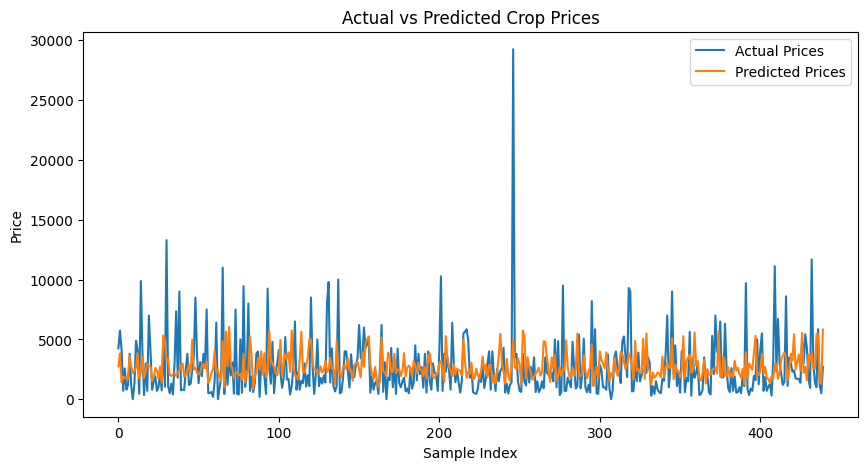

In [12]:
# 12. VISUALIZE → ACTUAL vs PREDICTED PRICES
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Prices")
plt.plot(best_model.predict(X_test), label="Predicted Prices")
plt.legend()
plt.title("Actual vs Predicted Crop Prices")
plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.show()

In [13]:
# 13. SAVE THE FINAL TRAINED MODEL
joblib.dump(best_model, "crop_price_model.pkl")
print("Model saved as crop_price_model.pkl")

Model saved as crop_price_model.pkl


In [14]:
from google.colab import files
files.download("crop_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>